#### **Setup, Environment, and Data Loading**

In [1]:
import pandas as pd
import plotly.express as pd_px
import plotly.io as pio
import os

# Ensure output directory exists for saved charts
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Load processed and output data
df_rankings = pd.read_csv("../outputs/country_rankings.csv")
df_ember = pd.read_csv("../data/processed/standardized_ember.csv")

print(f"Loaded Country Rankings: {df_rankings.shape}")
print(f"Loaded Standardized Ember Data: {df_ember.shape}")

df_rankings.head(3)

Loaded Country Rankings: (55, 6)
Loaded Standardized Ember Data: (22978, 25)


,Country,ISO3,Latest_Year,Completeness_Pct,Capacity_Coverage_Pct,Data_Quality_Score
0,South Africa,ZAF,2025,100.0,92.62,98.52
1,Morocco,MAR,2025,100.0,88.64,97.73
2,Rwanda,RWA,2024,100.0,88.24,97.65


#### **Top 10 Countries by Data Quality Score**

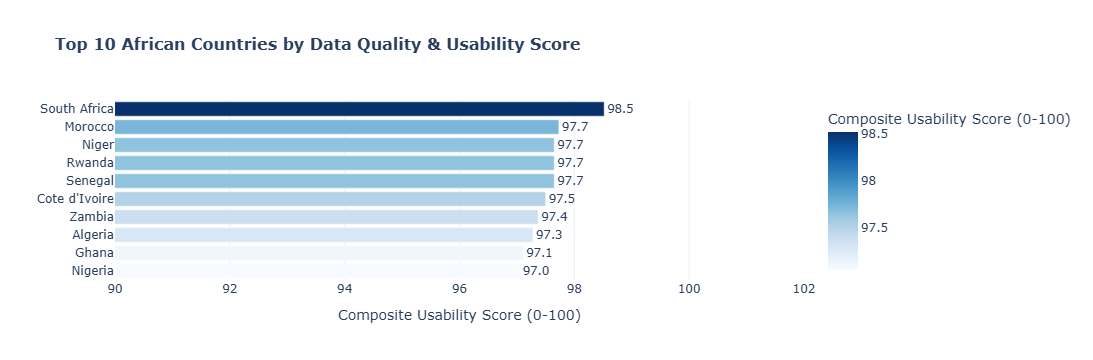

Interactive chart saved successfully to: ../outputs\top_10_country_quality_scores.html


In [2]:
import plotly.express as px

# Select top 10 countries
top_10_countries = df_rankings.head(10).sort_values(by="Data_Quality_Score", ascending=True)

# Create interactive horizontal bar chart
fig_scores = px.bar(
    top_10_countries,
    x="Data_Quality_Score",
    y="Country",
    orientation="h",
    title="<b>Top 10 African Countries by Data Quality & Usability Score</b>",
    labels={"Data_Quality_Score": "Composite Usability Score (0-100)", "Country": ""},
    text="Data_Quality_Score",
    color="Data_Quality_Score",
    color_continuous_scale="Blues"
)

fig_scores.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig_scores.update_layout(
    template="plotly_white",
    xaxis_range=[90, 102],
    title_font_size=16,
    showlegend=False
)

# Display the chart inside the notebook
fig_scores.show()

# Export chart assets to outputs folder
html_path = os.path.join(OUTPUT_DIR, "top_10_country_quality_scores.html")
fig_scores.write_html(html_path)
print(f"Interactive chart saved successfully to: {html_path}")

#### **Continental Electricity Generation Trends by Technology**

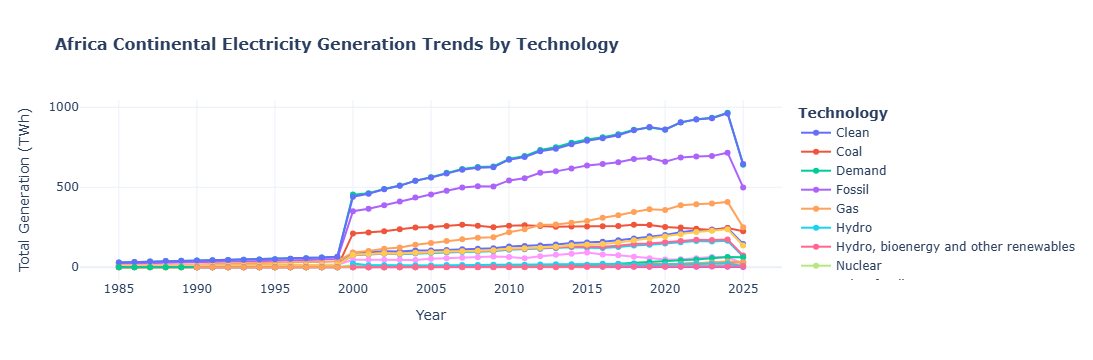

Interactive trend chart exported to: ../outputs\africa_generation_trends_by_technology.html


In [7]:
import pandas as pd
import plotly.express as px
import os

# Ensure output directory exists
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Ensure standardized Ember data is loaded if not already in memory
if 'df_ember' not in locals():
    df_ember = pd.read_csv("../data/processed/standardized_ember.csv")

# Aggregate country-level data by Year and Electricity source for the continent
df_continent_agg = (
    df_ember.groupby(['Year', 'Electricity source'], as_index=False)['Generation (TWh)']
    .sum()
)

# Create interactive multi-line chart
fig_trends = px.line(
    df_continent_agg,
    x="Year",
    y="Generation (TWh)",
    color="Electricity source",
    markers=True,
    title="<b>Africa Continental Electricity Generation Trends by Technology</b>",
    labels={
        "Generation (TWh)": "Total Generation (TWh)", 
        "Year": "Year", 
        "Electricity source": "Technology Source"
    }
)

fig_trends.update_layout(
    template="plotly_white",
    title_font_size=16,
    hovermode="x unified",
    legend_title_text="<b>Technology</b>"
)

# Display the interactive chart in the Jupyter Notebook
fig_trends.show()

# Export interactive chart asset to the outputs folder
trend_html_path = os.path.join(OUTPUT_DIR, "africa_generation_trends_by_technology.html")
fig_trends.write_html(trend_html_path)
print(f"Interactive trend chart exported to: {trend_html_path}")

#### **Top 10 African Countries Technology Mix**

Filtering latest reporting year: 2025


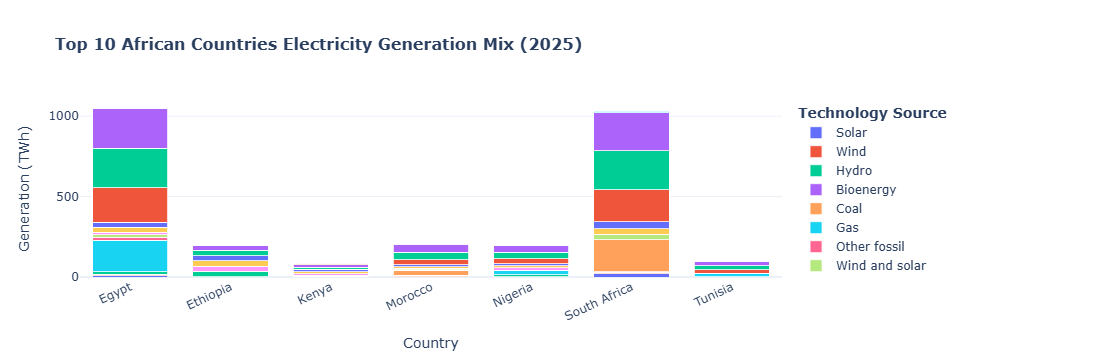

Interactive technology mix chart exported to: ../outputs\africa_technology_mix_latest.html


In [14]:
import pandas as pd
import plotly.express as px
import os

# Ensure output directory exists
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Determine the latest reporting year in the standardized dataset
latest_year = int(df_ember['Year'].max())
print(f"Filtering latest reporting year: {latest_year}")

# Filter data for the latest year and drop missing generation values
df_latest = df_ember[(df_ember['Year'] == latest_year) & (df_ember['Generation (TWh)'].notnull())].copy()

# Identify top 10 countries by total generation in that latest year
top_countries = (
    df_latest.groupby('Area')['Generation (TWh)']
    .sum()
    .nlargest(10)
    .index.tolist()
)

df_top_mix = df_latest[df_latest['Area'].isin(top_countries)]

# Create interactive stacked bar chart
fig_mix = px.bar(
    df_top_mix,
    x="Area",
    y="Generation (TWh)",
    color="Electricity source",
    title=f"<b>Top 10 African Countries Electricity Generation Mix ({latest_year})</b>",
    labels={
        "Area": "Country", 
        "Generation (TWh)": "Generation (TWh)", 
        "Electricity source": "Technology Source"
    },
    barmode="stack",
    hover_data=["ISO 3 code", "Generation (TWh)"]
)

fig_mix.update_traces(
    marker=dict(line=dict(width=0.8, color='white'))
)

fig_mix.update_layout(
    template="plotly_white",
    title_font_size=16,
    xaxis_tickangle=-25,
    legend_title_text="<b>Technology Source</b>",
    hovermode="closest",
    bargap=0.25
)

fig_mix.show(config={
    'displayModeBar': True,
    'modeBarButtonsToRemove': [],
    'toImageButtonOptions': {'format': 'png', 'filename': 'africa_tech_mix', 'height': 700, 'width': 1000}
})

# Export interactive chart asset to the outputs folder
mix_html_path = os.path.join(OUTPUT_DIR, "africa_technology_mix_latest.html")
fig_mix.write_html(mix_html_path)
print(f"Interactive technology mix chart exported to: {mix_html_path}")